# 1. Import Required Libraries

In [1]:

import numpy as np  # Importing NumPy for handling numerical data and arrays
import pandas as pd  # Importing Pandas for data manipulation and analysis

#------------ Importing visualization libraries ------------ #
import matplotlib.pyplot as plt  
import seaborn as sns  
import plotly.express as px  

#------------ Importing Machine Learning Libraries------------ #                                                    

# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split  

# Importing regression models for predictions

from sklearn.tree import DecisionTreeRegressor  # Decision Tree Regression model
from sklearn.ensemble import RandomForestRegressor  # Random Forest Regression model
from xgboost import XGBRegressor # XGBoost Regression model
from catboost import CatBoostRegressor # CatBoost Regressor model



#--------- Importing Libraries for Model Evaluation -------------- #

# Importing evaluation metrics to measure model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  
#  Adding Root Mean Absolute Error (RMAE)
def root_mean_absolute_error(y_true, y_pred):
    return np.sqrt(mean_absolute_error(y_true, y_pred))

    
#--------- Data Preprocessing  ------------------ #

# Converting categorical values into numerical 
from sklearn.preprocessing import OrdinalEncoder  

  


#-------- Disabling Warnings for a Cleaner Output------------- #

import warnings
warnings.filterwarnings('ignore')

# 2. Load Datasets

In [2]:
# Loading The Dataset #
diamonds =  pd.read_csv("diamonds2.csv")
#  The First Few Rows
styled_diamonds = diamonds.head().style.set_properties(**{
    'background-color': 'white',
    'color': '#1E3A8A',
    'border-color': 'gold'
})

display(styled_diamonds)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.230000,Ideal,E,SI2,61.500000,55.000000,326,3.950000,3.980000,2.430000
1,2,0.210000,Premium,E,SI1,59.800000,61.000000,326,3.890000,3.840000,2.310000
2,3,0.230000,Good,E,VS1,56.900000,65.000000,327,4.050000,4.070000,2.310000
3,4,0.290000,Premium,I,VS2,62.400000,58.000000,334,4.200000,4.230000,2.630000
4,5,0.310000,Good,J,SI2,63.300000,58.000000,335,4.340000,4.350000,2.750000


# 3. Data Exploration

### 3.1 Descriptive Analysis

In [5]:
# Number of rows and columns
(diamonds.shape)  

(53940, 11)

In [7]:
# View data information
(diamonds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [9]:
# The number of repetitions in each cut category
diamonds["cut"].value_counts()  

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [11]:
# The number of repetitions in each color category
diamonds["cut"].value_counts()  

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [13]:
# The number of repetitions in each clarity category
diamonds["clarity"].value_counts()

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

In [15]:
# Metastatistics of numerical data
import pandas as pd
selected_columns = ['carat', 'depth', 'table', 'price', 'x' , 'y' , 'z']
styled_df = diamonds[selected_columns].describe().style.set_properties(**{
    'background-color': 'white',   
    'color': 'brown',              
    'border-color': 'gold',        
    'font-size': '12pt',           
    'text-align': 'center'         
})

display(styled_df)


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [17]:
# Counting the number of missing values
diamonds.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

### 3.2 Visualization

###  Univariate Analysis

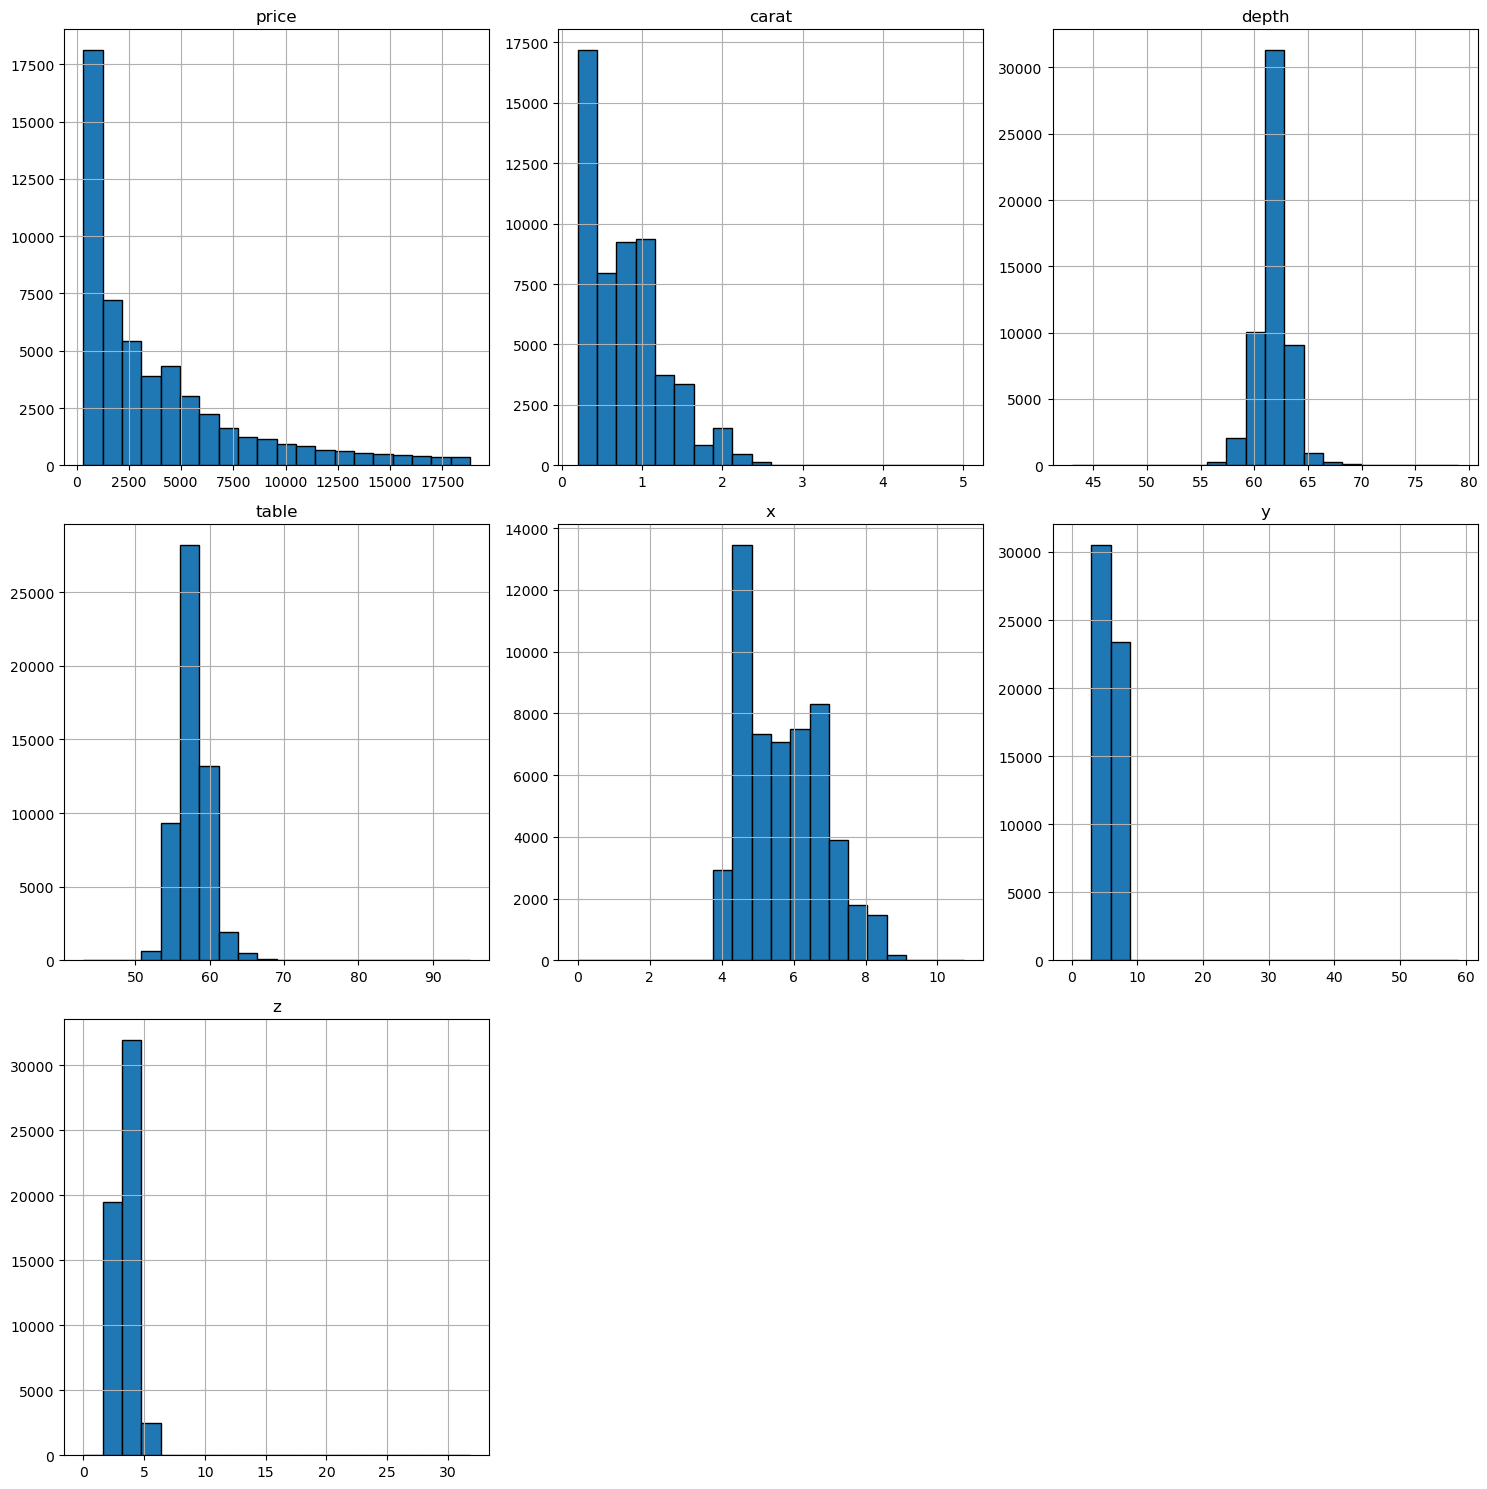

In [19]:
# Plotting Histograms to Visualize Data Distribution
# Numerical columns
selected_columns = ["price", "carat", "depth", "table", "x", "y", "z"]
diamonds[selected_columns].hist(bins=20, figsize=(15, 15), edgecolor='black')
plt.tight_layout()
plt.show()

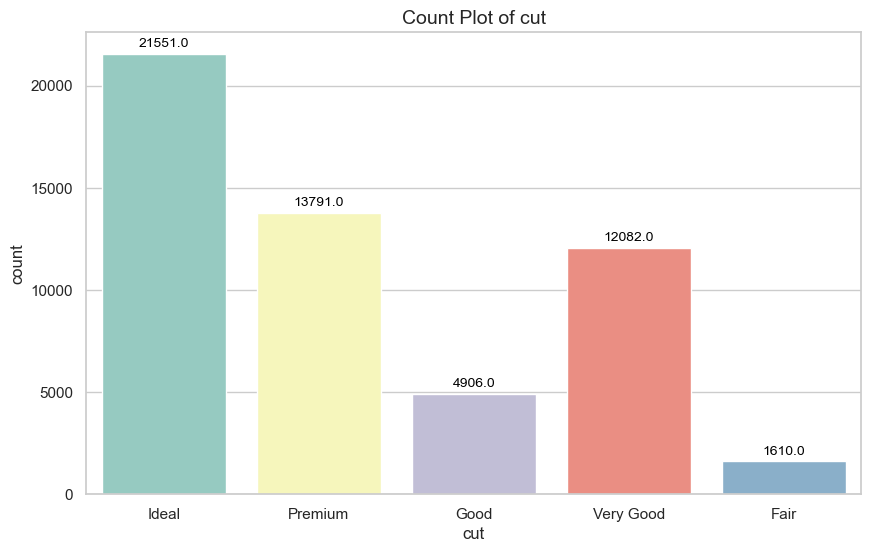

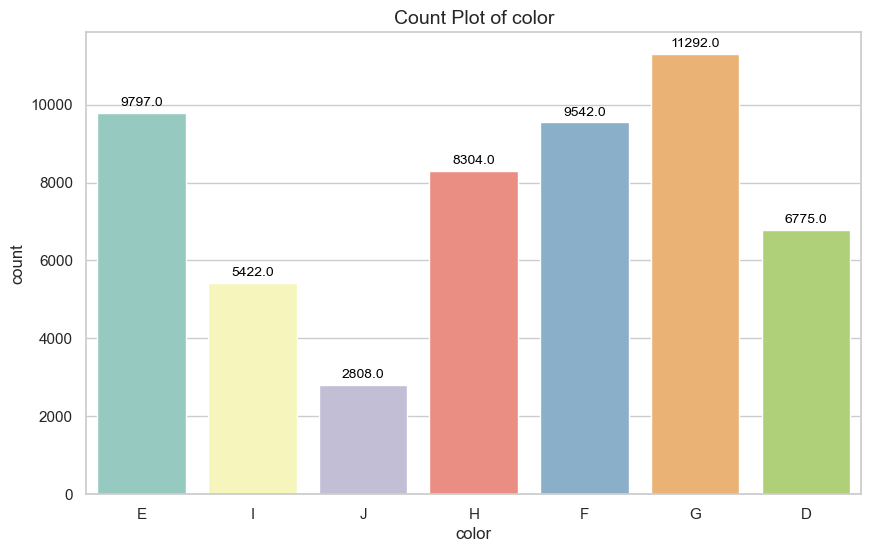

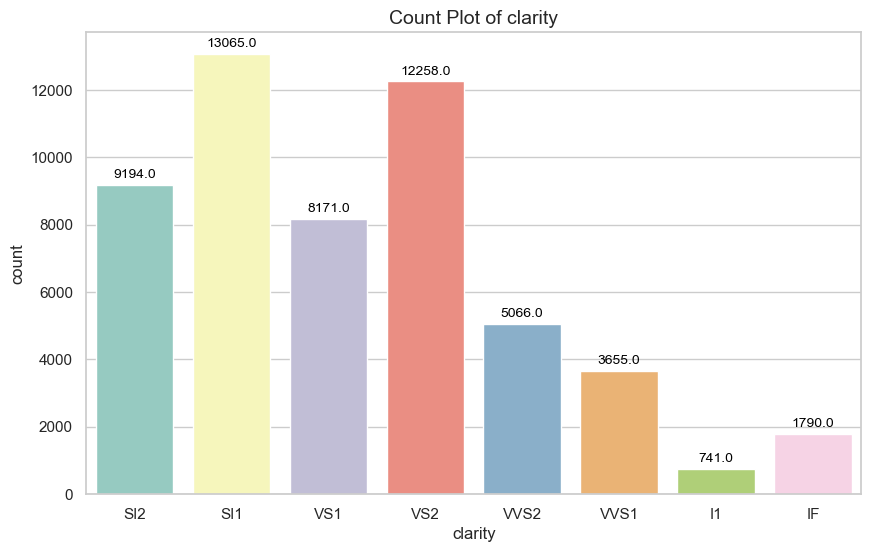

In [21]:
# Count Plot Visualization for Categorical Data Distribution
# Categorical columns

# Define categorical columns
object_cols = ["cut", "color", "clarity"]  

#Plot count plots for each categorical column
for c in object_cols:
    plt.figure(figsize=(10, 6)) #Set figure size
   # Set plot style 
    sns.set(style="whitegrid")
    ax = sns.countplot(x=diamonds[c], palette="Set3")
    
    # Add count annotations on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', # Display count value
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, 
                    color='black', xytext=(0, 5),
                    textcoords='offset points')
    # title
    plt.title(f'Count Plot of {c}', fontsize=14)
    plt.show()

###  Bivariate Analysis

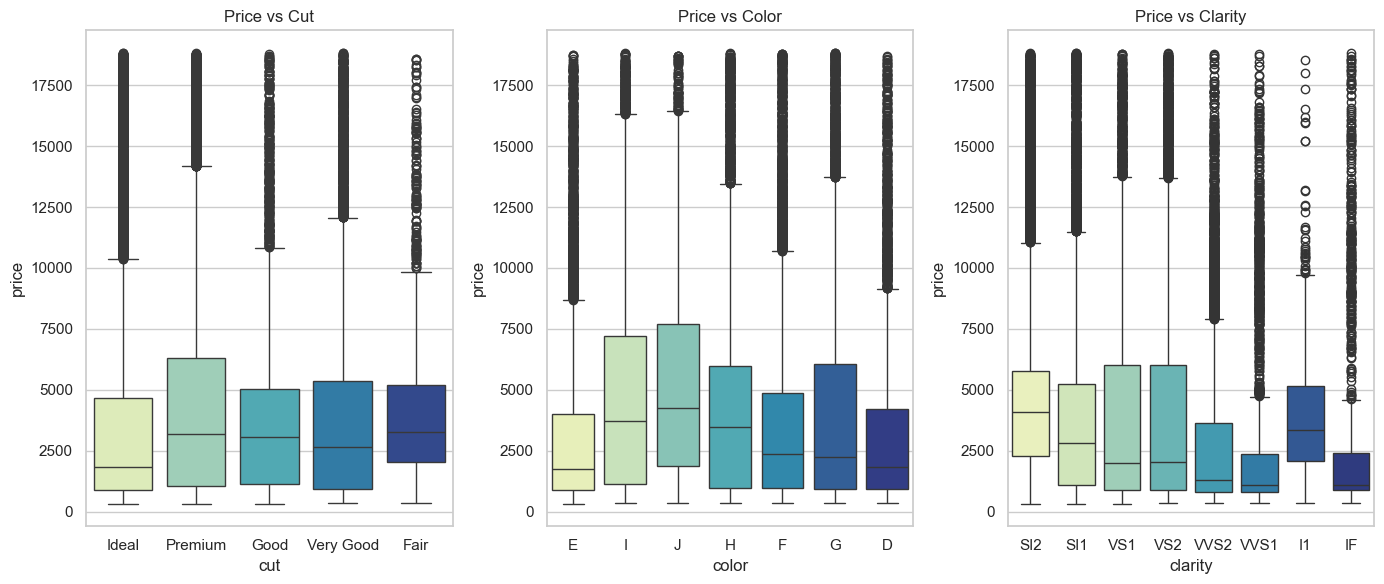

In [23]:
# Comparing Price Distribution Based on Cut, Color, and Clarity Using Boxplot
plt.figure(figsize=(14,6))

# Price vs Cut
plt.subplot(1, 3, 1)
sns.boxplot(x='cut', y='price', data=diamonds, palette='YlGnBu')
plt.title('Price vs Cut', fontsize=12)

# Price vs Color
plt.subplot(1, 3, 2)
sns.boxplot(x='color', y='price', data=diamonds, palette='YlGnBu')
plt.title('Price vs Color', fontsize=12)

# Price vs Clarity
plt.subplot(1, 3, 3)
sns.boxplot(x='clarity', y='price', data=diamonds, palette='YlGnBu')
plt.title('Price vs Clarity', fontsize=12)

plt.tight_layout()
plt.show()

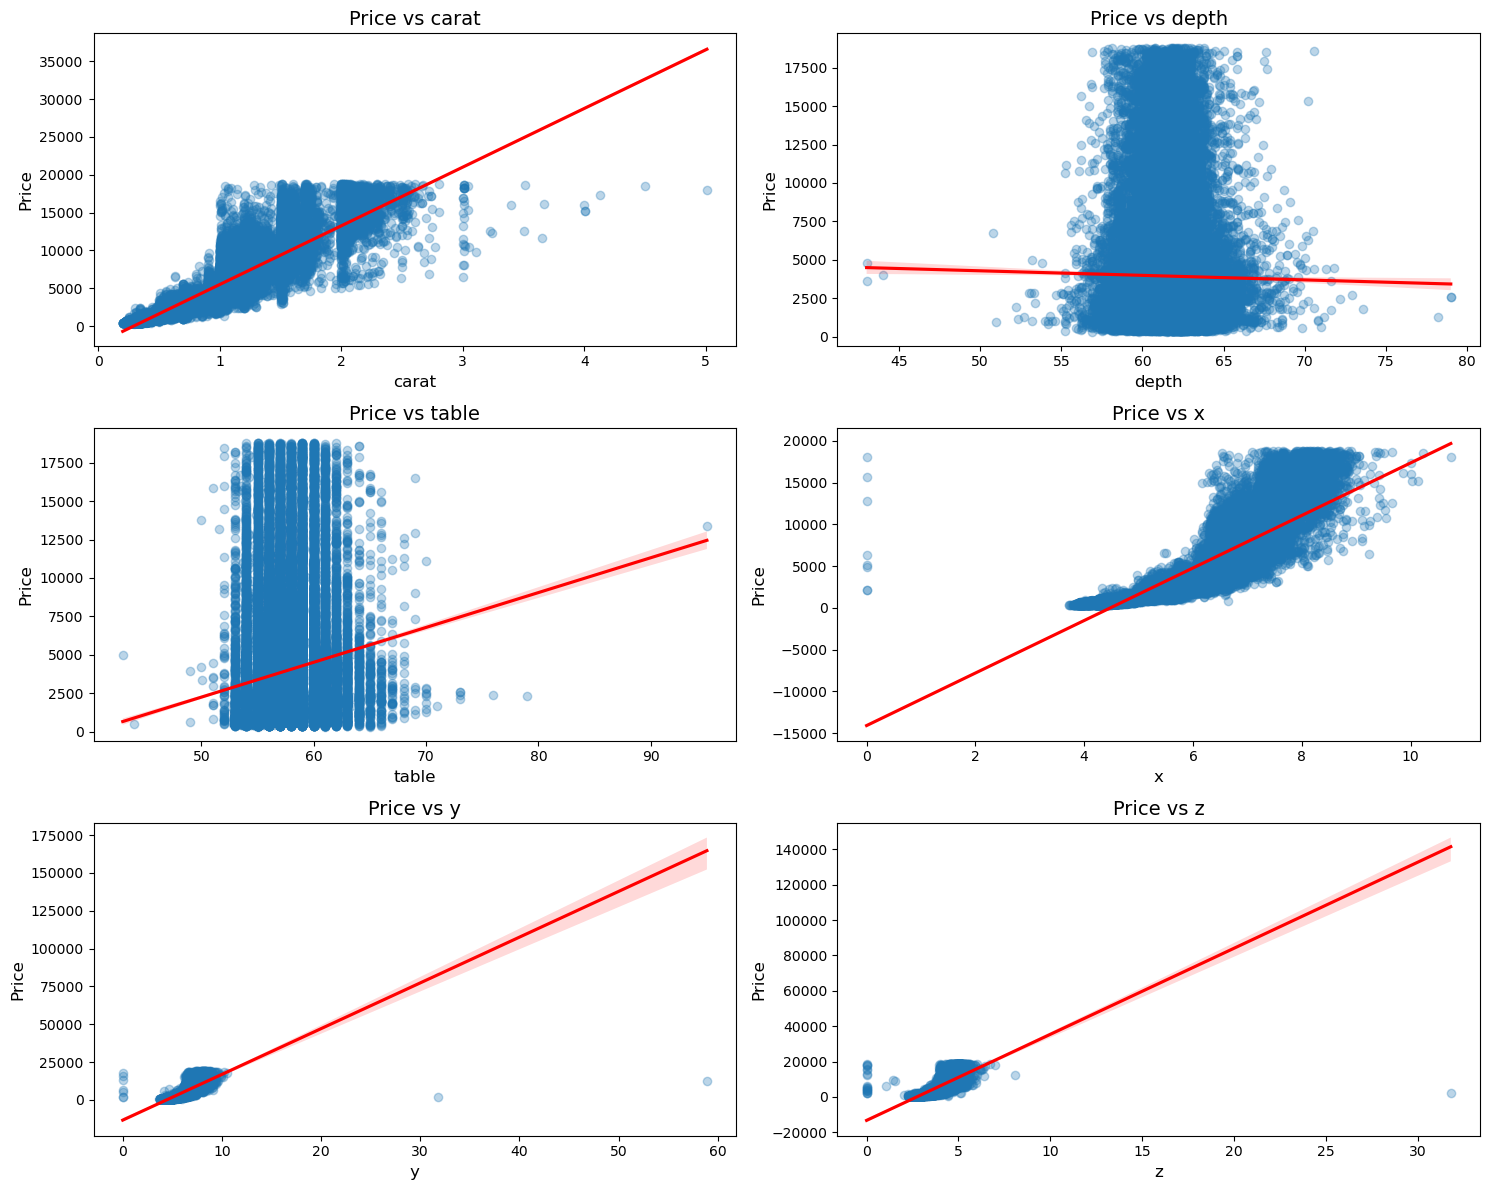

In [5]:
#  Relationship Between Price and Numerical Features Using Regression Plots
import matplotlib.pyplot as plt
import seaborn as sns

# Defining the numerical columns to analyze their relationship with price
numeric_columns = ["carat", "depth", "table", "x", "y", "z"]

# Creating the chart

plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 2, i)
    sns.regplot(x=diamonds[col], y=diamonds["price"], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f"Price vs {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Price", fontsize=12)

plt.tight_layout()
plt.show()

###  Multivariate Analysis

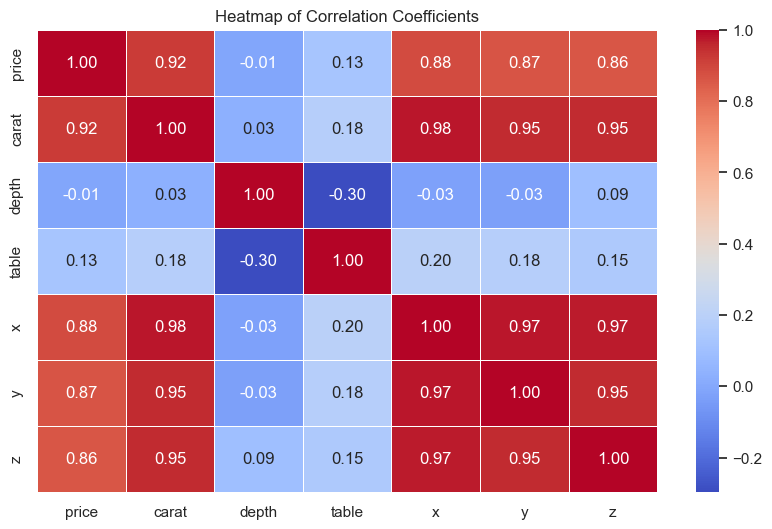

In [25]:
# Creating a Heatmap for Correlation Matrix of Numerical Variables
import seaborn as sns
import matplotlib.pyplot as plt

    
numeric_cols = diamonds.select_dtypes(include=['number'])

# Calculating the correlation matrix
correlation_matrix =diamonds [["price", "carat", "depth", "table", "x", "y", "z"]].corr()

# Creating the heatmap using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Correlation Coefficients")
plt.show()

# 4 Cleaning & PreProcessing:
### 4.1 Remove the column

In [5]:
# Drop the "Unnamed: 0" column
diamonds = diamonds.drop("Unnamed: 0", axis = 1)

### 4.2 Outiers

In [7]:
# Remove Outliers #

# Define numerical columns
num_cols = ['carat', 'depth', 'table','price', 'x', 'y', 'z']
diamonds2 = diamonds.copy()  
# remove outliers using the (IQR) method
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)  # First quartile
    Q3 = data[column].quantile(0.75)  # Third quartile
    IQR = Q3 - Q1  # Calculate the Interquartile Range (IQR) 
    lower_bound = Q1 - 1.5 * IQR  # Define lower bound for acceptable values
    upper_bound = Q3 + 1.5 * IQR  # Define upper bound for acceptable values 
    
    # Filter out rows that fall outside the acceptable range
    filtered_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return filtered_data
# Apply outlier removal function to each numerical column
for col in num_cols:
    diamonds2 = remove_outliers_iqr(diamonds2, col)  

# Display dataset statistics before and after outlier removal
print(f'rows before cleaning: {len(diamonds)}')
print(f'rows after cleaning: {len(diamonds2)}')


rows before cleaning: 53940
rows after cleaning: 46532


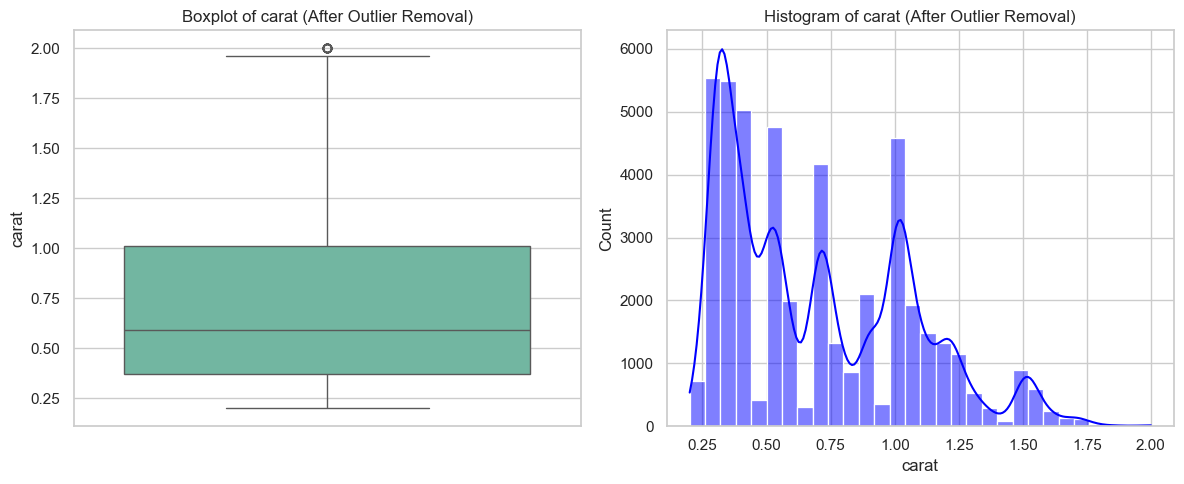

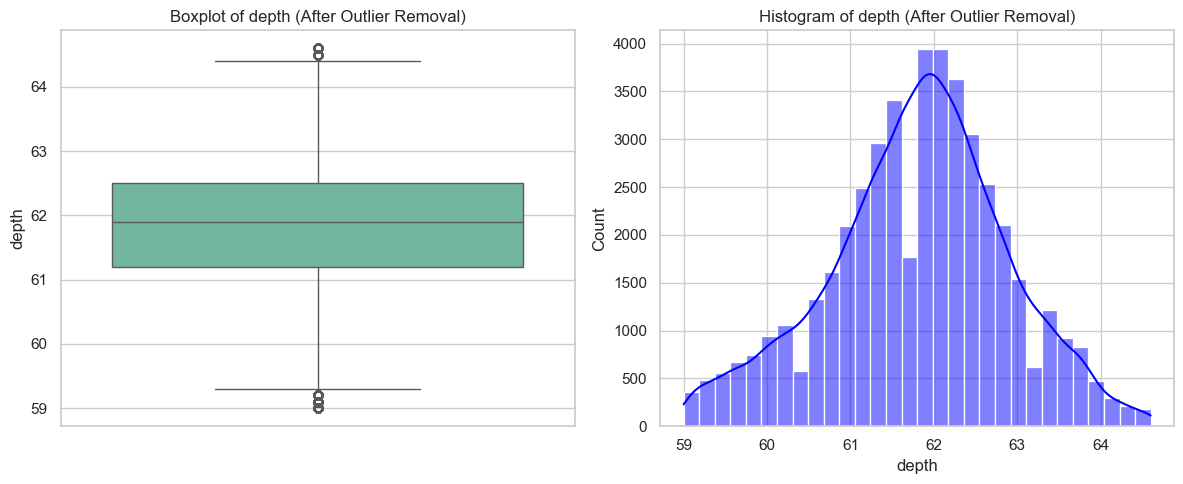

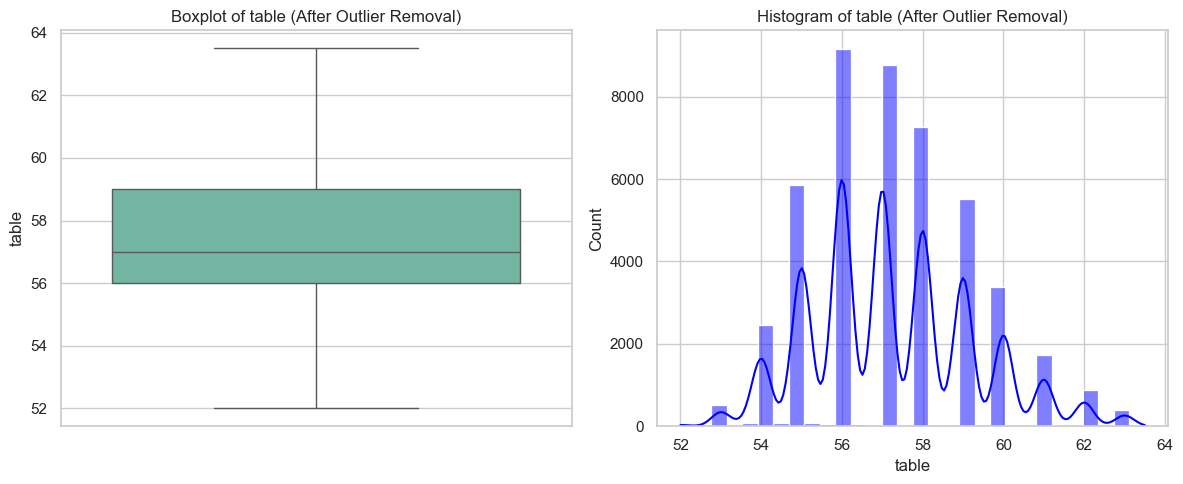

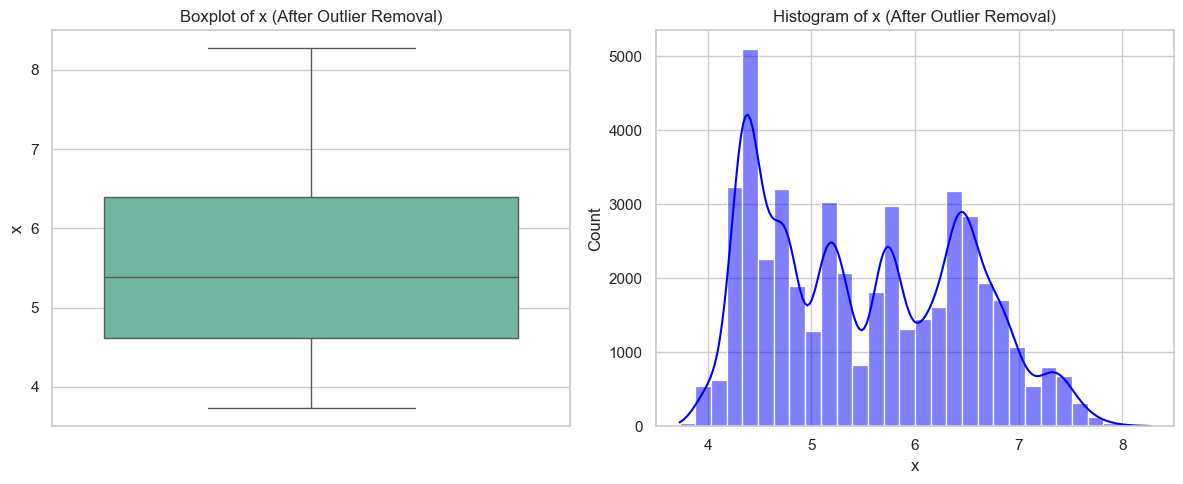

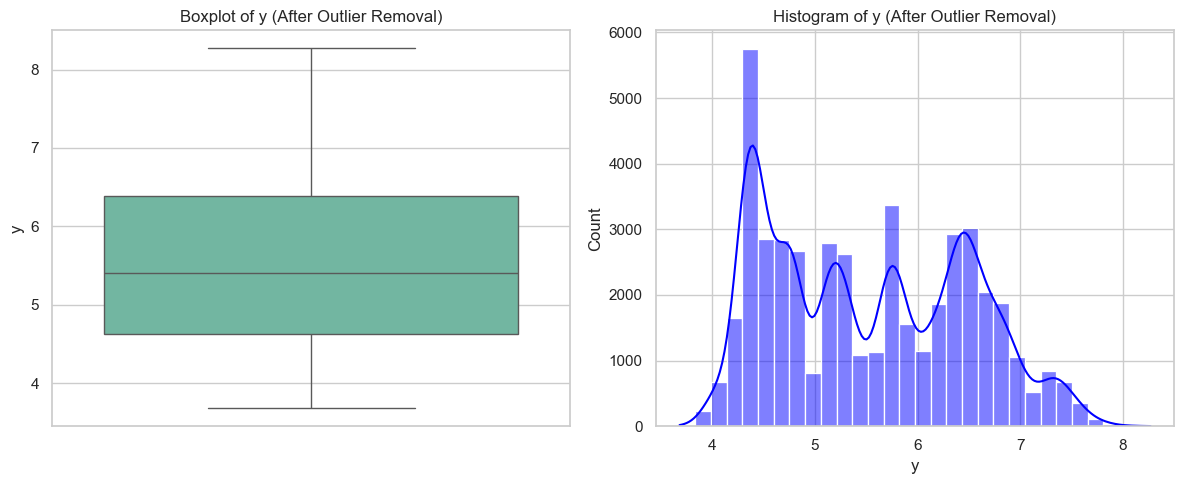

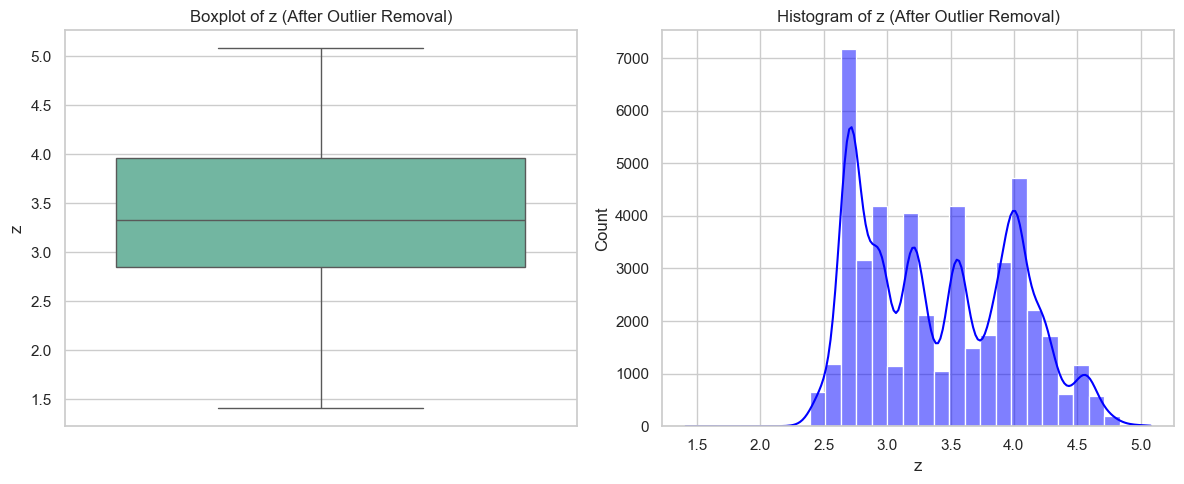

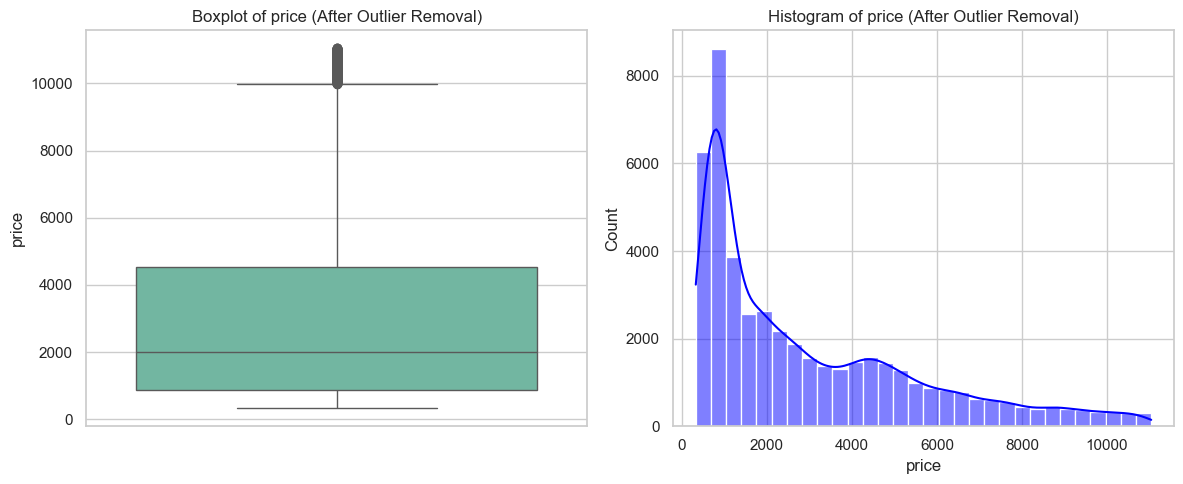

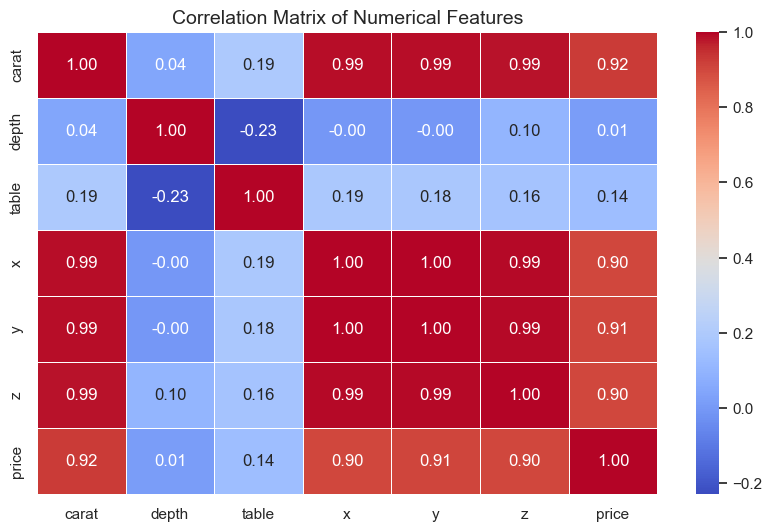

In [31]:
# Data visualizations after removing outlies 

# List of numerical columns 
numeric_cols = ["carat", "depth", "table", "x", "y", "z", "price"]

#  Plot distribution for each numerical column
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Create 2 plots side by side

    #  Boxplot (To identify outliers)
    sns.boxplot(y=diamonds2[col], palette="Set2", ax=axes[0])
    axes[0].set_title(f'Boxplot of {col} (After Outlier Removal)', fontsize=12)

    #  Histogram (To show data distribution)
    sns.histplot(diamonds2[col], bins=30, kde=True, color="blue", ax=axes[1])
    axes[1].set_title(f'Histogram of {col} (After Outlier Removal)', fontsize=12)

    #  Improve layout
    plt.tight_layout()
    plt.show()

#  Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(diamonds2[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.show()

### 4.3 Encoding

In [9]:

from sklearn.preprocessing import OrdinalEncoder
# Define category order for ordinal encoding (from lowest to highest rank)
cut_categories = ['Fair','Good', 'Very Good', 'Premium', 'Ideal']
clarity_categories = ['I1','SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1','IF']
color_categories = ['J','I','H','G','F','E','D']
# Initialize the Ordinal Encoder with predefined category orders
ordinal_enc = OrdinalEncoder(categories=[cut_categories, clarity_categories, color_categories])
# Apply encoding to categorical features in diamonds2 and shift values by +1 (so it starts from 1)
diamonds2[['cut', 'clarity','color']] = ordinal_enc.fit_transform(diamonds2[['cut', 'clarity','color']]) + 1


### 4.5 Transfers

In [11]:
# Convert " price" column from int64 to float64
diamonds2["price"] = diamonds2["price"].astype('float64')
print(diamonds2.head())

   carat  cut  color  clarity  depth  table  price     x     y     z
0   0.23  5.0    6.0      2.0   61.5   55.0  326.0  3.95  3.98  2.43
1   0.21  4.0    6.0      3.0   59.8   61.0  326.0  3.89  3.84  2.31
3   0.29  4.0    2.0      4.0   62.4   58.0  334.0  4.20  4.23  2.63
4   0.31  2.0    1.0      2.0   63.3   58.0  335.0  4.34  4.35  2.75
5   0.24  3.0    1.0      6.0   62.8   57.0  336.0  3.94  3.96  2.48


### 6.4 Test Set

In [13]:
# Defining Features and Target Variable #
# Selecting variables independent (X) and dependent variable (y)
X = diamonds2.drop(['price'], axis=1) # Dropping the price column since it's the target variable
y = diamonds2['price'] # Selecting the price column as the target variable to pred

# Splitting Data into Training and Testing Sets #
# Splitting the data into 80% training and 20% testing
# The training set is used to train the model, while the test set is used to evaluate its performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" X_train: {X_train.shape},  X_test: {X_test.shape}")

 X_train: (37225, 9),  X_test: (9307, 9)


# 5. Model Building

###  5.1 Decision Tree Regression

In [41]:
# ---------------------------------------------------------- #
# Training and Evaluating the Decision Tree Regression Model #
# ----------------------------------------------------------- #


# Creating and Training the Model #

# Initializing the Decision Tree model with a fixed random state to ensure consiste
dt_model = DecisionTreeRegressor(random_state=42)
# Training the model using the training dataset (X_train and y_train)
dt_model.fit(X_train, y_train)

# Making Predictions #

# Using the trained model to predict prices based on the test dataset (X_test)
y_pred_dt = dt_model.predict(X_test)

# Evaluating the Model's Performance #

# Calculating Mean Absolute Error (MAE) Measures the average absolute difference betwen acetual and predicted values
mae_dt = mean_absolute_error(y_test, y_pred_dt)
# Calculating Mean Squared Error (MSE) Measures the squared differences between actual and predicted values
mse_dt = mean_squared_error(y_test, y_pred_dt)
# Calculating Root Mean Squared Error (RMSE)
# RMSE is the square root of MSE and represents the model's error in the same units as the target variable
rmse_dt = mean_squared_error(y_test, y_pred_dt, squared=False)
# Calculating R² Score - Measures how well the model explains the variance in the data (closer to 1 is better)
r2_dt = r2_score(y_test, y_pred_dt)

print("\n Decision Tree Performance:")
print(f" MAE: {mae_dt:.4f}")
print(f" MSE: {mse_dt:.4f}")
print(f" RMSE: {rmse_dt:.4f}")
print(f" R² Score: {r2_dt:.4f}")


 Decision Tree Performance:
 MAE: 249.6853
 MSE: 213345.9566
 RMSE: 461.8939
 R² Score: 0.9683


### 5.2 Random Forest Regression

In [43]:
# ---------------------------------------------------------- #
# Training and Evaluating the Random Forest Regression Model
# ----------------------------------------------------------- #

# Creating and Training the Model #

# Initializing the Random Forest model with a fixed random state to ensure consistent results
rf_model = RandomForestRegressor(random_state=42)
# Training the model using the training dataset (X_train and y_train)
rf_model.fit(X_train, y_train)

# Making Predictions #

# Using the trained model to predict prices based on the test dataset (X_test)
y_pred_rf = rf_model.predict(X_test)

# Evaluating the Model's Performance #

# Calculating Mean Absolute Error (MAE) Measures the average absolute difference between actual and predicted values
mae_rf = mean_absolute_error(y_test, y_pred_rf)
# Calculating Mean Squared Error (MSE) Measures the squared differences between actual and predicted values
mse_rf = mean_squared_error(y_test, y_pred_rf)
# Calculating Root Mean Squared Error (RMSE)
# RMSE is the square root of MSE and represents the model's error in the same units as the target variable.
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
# Calculating R² Score - Measures how well the model explains the variance in the data (closer to 1 is better)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n Random Forest Performance:")
print(f" MAE: {mae_rf:.4f}")
print(f" MSE: {mse_rf:.4f}")
print(f" RMSE: {rmse_rf:.4f}")
print(f" R² Score: {r2_rf:.4f}")


 Random Forest Performance:
 MAE: 188.9253
 MSE: 114980.2474
 RMSE: 339.0874
 R² Score: 0.9829


### 5.3 XGBoost Regression

In [45]:
# ---------------------------------------------------------- #
# Training and Evaluating the XGBoost Regression Model
# ----------------------------------------------------------- #

# Creating and Training the Model #

# Initializing the XGBoost model with a fixed random state to ensure consistent results
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
# Training the model using the training dataset (X_train and y_train)
xgb_model.fit(X_train, y_train)

# Making Predictions #

y_pred_xgb = xgb_model.predict(X_test)

# Evaluating the Model's Performance #

# Calculating Mean Absolute Error (MAE) Measures the average absolute difference between actual and predicted values
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
# Calculating Mean Squared Error (MSE) Measures the squared differences between actual and predicted values
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
# Calculating Root Mean Squared Error (RMSE)
# RMSE is the square root of MSE and represents the model's error in the same units as the target variable.
rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)
# Calculating R² Score - Measures how well the model explains the variance in the data (closer to 1 is better)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n XGBoost Performance:")
print(f" MAE: {mae_xgb:.4f}")
print(f" MSE: {mse_xgb:.4f}")
print(f" RMSE: {rmse_xgb:.4f}")
print(f" R² Score: {r2_xgb:.4f}")


 XGBoost Performance:
 MAE: 191.7298
 MSE: 112717.3253
 RMSE: 335.7340
 R² Score: 0.9833


### 5.4 CatBoost Regression

In [47]:
# ---------------------------------------------------------- #
# Training and Evaluating the CatBoost Regression Model
# ----------------------------------------------------------- #

# Creating and Training the Model #

# Initializing the CatBoost model with a fixed random state to ensure consistent results
cat_model = CatBoostRegressor(random_seed=42, verbose=0)
# Training the model using the training dataset (X_train and y_train)
cat_model.fit(X_train, y_train)

# Making Predictions #

y_pred_cat = cat_model.predict(X_test)

# Evaluating the Model's Performance #

# Calculating Mean Absolute Error (MAE) Measures the average absolute difference between actual and predicted values
mae_cat = mean_absolute_error(y_test, y_pred_cat)
# Calculating Mean Squared Error (MSE) Measures the squared differences between actual and predicted values
mse_cat = mean_squared_error(y_test, y_pred_cat)
# Calculating Root Mean Squared Error (RMSE)
# RMSE is the square root of MSE and represents the model's error in the same units as the target variable.
rmse_cat = mean_squared_error(y_test, y_pred_cat, squared=False)
# Calculating R² Score - Measures how well the model explains the variance in the data (closer to 1 is better)
r2_cat = r2_score(y_test, y_pred_cat)

print("\n CatBoost Performance:")
print(f" MAE: {mae_cat:.4f}")
print(f" MSE: {mse_cat:.4f}")
print(f" RMSE: {rmse_cat:.4f}")
print(f" R² Score: {r2_cat:.4f}")


 CatBoost Performance:
 MAE: 187.5080
 MSE: 107912.5853
 RMSE: 328.5005
 R² Score: 0.9840


### 5.5 Results comparison table 

In [49]:
# ---------------------------------- #
# Model Performance Comparison Table #
# ---------------------------------- #
import pandas as pd
from tabulate import tabulate

# models

comparison_table = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost", "CatBoost"],
    "MAE": [mae_dt, mae_rf, mae_xgb, mae_cat],
    "MSE": [mse_dt, mse_rf, mse_xgb, mse_cat],
    "RMSE": [rmse_dt, rmse_rf, rmse_xgb, rmse_cat],
    "R² Score": [r2_dt, r2_rf, r2_xgb, r2_cat]
})


comparison_table = comparison_table.round(4)


print(tabulate(comparison_table, headers='keys', tablefmt='fancy_grid' , floatfmt=".4f"))

╒════╤═══════════════╤══════════╤═════════════╤══════════╤════════════╕
│    │ Model         │      MAE │         MSE │     RMSE │   R² Score │
╞════╪═══════════════╪══════════╪═════════════╪══════════╪════════════╡
│  0 │ Decision Tree │ 249.6853 │ 213345.9566 │ 461.8939 │     0.9683 │
├────┼───────────────┼──────────┼─────────────┼──────────┼────────────┤
│  1 │ Random Forest │ 188.9253 │ 114980.2474 │ 339.0874 │     0.9829 │
├────┼───────────────┼──────────┼─────────────┼──────────┼────────────┤
│  2 │ XGBoost       │ 191.7298 │ 112717.3253 │ 335.7340 │     0.9833 │
├────┼───────────────┼──────────┼─────────────┼──────────┼────────────┤
│  3 │ CatBoost      │ 187.5080 │ 107912.5853 │ 328.5005 │     0.9840 │
╘════╧═══════════════╧══════════╧═════════════╧══════════╧════════════╛


### 5.6 Visualize comparing results

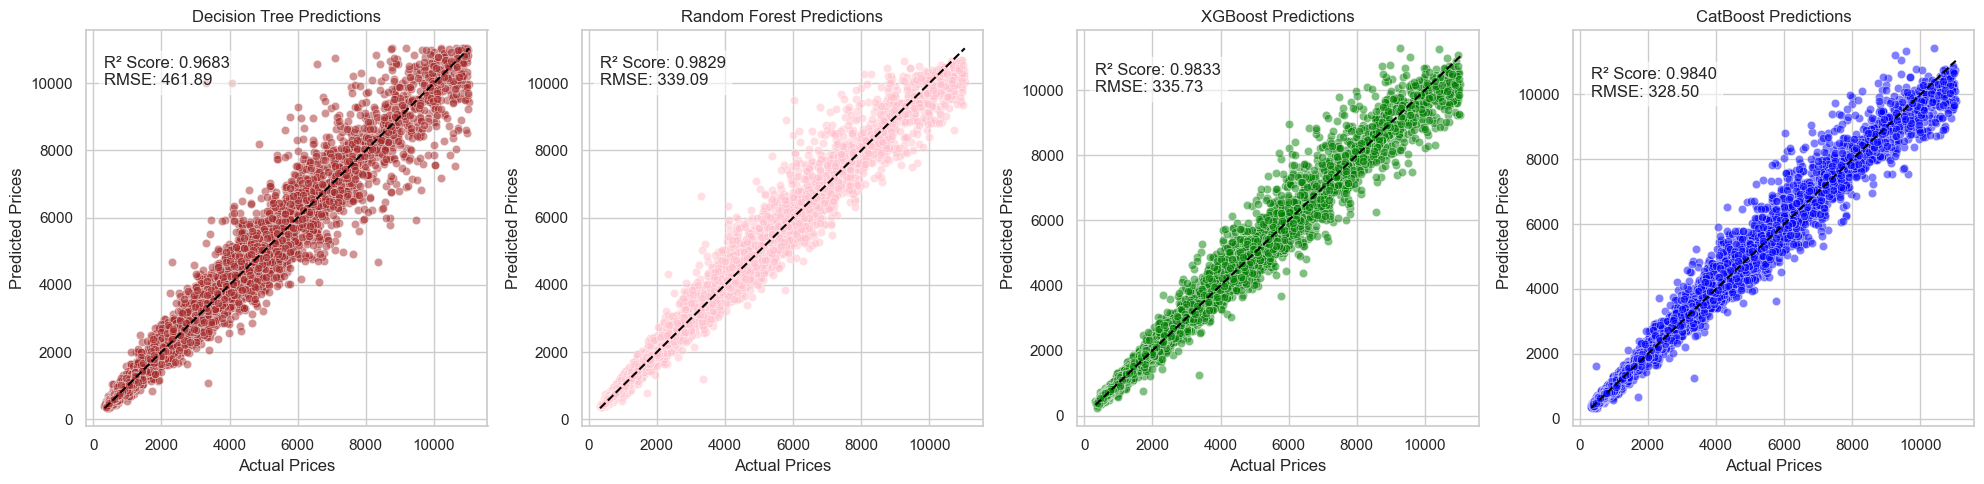

In [51]:
# --------------------------------------------------- #
# Plotting Actual vs. Predicted Values for Each Model #
# --------------------------------------------------- #

import matplotlib.pyplot as plt
import seaborn as sns

# models

models = ["Decision Tree", "Random Forest", "XGBoost", "CatBoost"]
predictions = [y_pred_dt, y_pred_rf, y_pred_xgb, y_pred_cat]
r2_scores = [r2_dt, r2_rf, r2_xgb, r2_cat]
rmse_scores = [rmse_dt, rmse_rf, rmse_xgb, rmse_cat]
colors = ["brown", "pink", "green", "blue"]


plt.figure(figsize=(20, 5))

for i, (model, y_pred, r2, rmse, color) in enumerate(zip(models, predictions, r2_scores, rmse_scores, colors), 1):
    plt.subplot(1, 4, i)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color=color)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="black")
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(f"{model} Predictions")

    # Adding statistics within the drawing
    stats_text = f"R² Score: {r2:.4f}\nRMSE: {rmse:.2f}"
    plt.text(x=min(y_test), y=max(y_test)*0.9, s=stats_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.6))


plt.tight_layout()
plt.show()